### **Algorithm : Multinomial Naive Bayes** 

### **Project:** 
    
 **Fake News Detection**

### **Problem Statement:**

 **Classify news articles as fake or real using textual word frequencies.**

In [23]:
# Step No 1 : Import Required Libraries 

# Import numerical library 
import numpy as np 

# Import data manipulation library 
import pandas as pd 

# Import data visualization libraries 
import matplotlib.pyplot as plt 

# Import Advanced Data Visualization Libraries 
import seaborn as sns 

# Import Machine Learning Libraries 
# Import train test split library 
from sklearn.model_selection import train_test_split 

# Import TF-IDF Vectorizer library
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Multinomial Naive Bayes 
from sklearn.naive_bayes import MultinomialNB

# Import Evaluation Metrics Libraries 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

In [24]:
# Step No 2 : Load the Dataset 
df = pd.read_csv("Fake_News_Detection_Dataset.csv")

In [25]:
# Step No 3 : Data Preporcessing and Understanding

# Display the first 5 rows 
print(df.head())

# Display dataset shape 
print("\nDataset Shape : ")
print(df.shape)

# Display dataset columns names 
print("\nDataset Columns Names : ")
print(df.columns)

# Display dataset information 
print("\nDataset Information : ")
print(df.info())

# Display dataset mathematical description
print("\nDataset Description : ")
print(df.describe())

   NewsID  ... Label
0       1  ...  Real
1       2  ...  Fake
2       3  ...  Real
3       4  ...  Fake
4       5  ...  Real

[5 rows x 4 columns]

Dataset Shape : 
(1000, 4)

Dataset Columns Names : 
Index(['NewsID', 'Title', 'Text', 'Label'], dtype='object')

Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NewsID  1000 non-null   int64 
 1   Title   1000 non-null   object
 2   Text    1000 non-null   object
 3   Label   1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB
None

Dataset Description : 
            NewsID
count  1000.000000
mean    500.500000
std     288.819436
min       1.000000
25%     250.750000
50%     500.500000
75%     750.250000
max    1000.000000


In [26]:
# Step No 4 : Data Cleaning 

# Check missing values in the dataset 
print("\nMissing Values in the Dataset : ")
print(df.isnull().sum())

# Check for duplicate values in the dataset 
print("\nDuplicate Values in the Dataset : ")
print(df.duplicated().sum())

# Drop duplicate values from the dataset 
print("\nDropping Duplicate Values from the Dataset ")
df = df.drop_duplicates()


Missing Values in the Dataset : 
NewsID    0
Title     0
Text      0
Label     0
dtype: int64

Duplicate Values in the Dataset : 
0

Dropping Duplicate Values from the Dataset 


In [27]:
# Step No 5 : Handle Missing Text Values and  display target distribution

# Replace missing Title values with empty string
df["Title"] = df["Title"].fillna("")

# Replace missing Text values with empty string 
df["Text"] = df["Text"].fillna("")

# Combine Title and Text
df["NewsContent"] = (
    df["Title"] + " " + df["Text"]
)

# Display target distribution
print("\nLabel Distribution : ")
print(df["Label"].value_counts())


Label Distribution : 
Label
Fake    501
Real    499
Name: count, dtype: int64


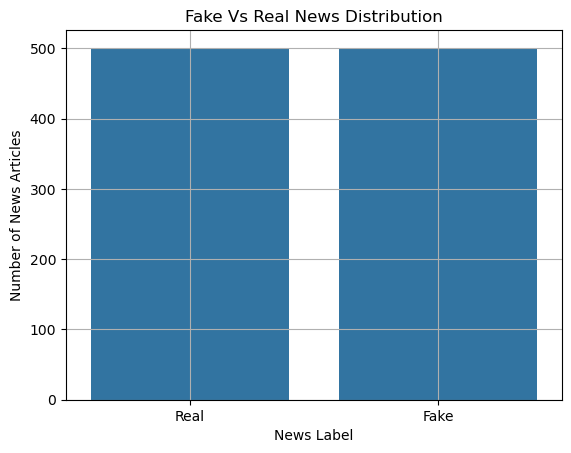

In [28]:
# Step No 6 : Data Visualization 

# Create count plot 
sns.countplot(x = "Label" , data = df )

# Set Plot Title 
plt.title("Fake Vs Real News Distribution")

# Set x-axis label 
plt.xlabel("News Label")

# Set y-axis Label
plt.ylabel("Number of News Articles")

# Save the plot as an image file 
plt.savefig("Fake_News_Distribution.png")

# Enable grid 
plt.grid()

# Display the plot 
plt.show()

In [29]:
# Step No 7 : Define Input and Target Variables 

# Define input variable X 
X = df["NewsContent"]

# Define target variable y 
y = df["Label"]

In [30]:
# Step No 8 : Split the Dataset into Training and Testing Sets 
X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y ,
    test_size = 0.20 ,
    random_state = 42 
)

In [31]:
# Step No 9 : TF - IDF Vectorization 
vectorizer = TfidfVectorizer(
    lowercase = True , 
    stop_words = "english",
    max_features = 5000,
    ngram_range = (1, 2)
)

In [32]:
# Step No 10 : Fit and Transform the Training Data 

# Learn vocabulary from training data and convert training data into feature vectors
X_train_vectorized = vectorizer.fit_transform(X_train)

# Learn vocabulary from testing data and convert testing data into feature vectors
X_test_vectorized = vectorizer.transform(X_test)

In [33]:
# Step No 11 : Display Vectorized Data Shape 

print("\nTraining Vector Shape : ")
print(X_train_vectorized.shape)

print("\nTesting Vector Shape : ")
print(X_test_vectorized.shape)


Training Vector Shape : 
(800, 319)

Testing Vector Shape : 
(200, 319)


In [34]:
# Step No 12 : Create Multinomial Naive Bayes Model 

model = MultinomialNB()

In [35]:
# Step No 13 : Train the Model 
# Train model using TF-IDF features 
model.fit(
    X_train_vectorized , 
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [36]:
# Step No 14 : Predict Test Data 
# Predict labels for test data 
y_pred = model.predict(
    X_test_vectorized
)

# Display prediction 
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
['Real' 'Real' 'Fake' 'Real' 'Real' 'Real' 'Fake' 'Fake' 'Fake' 'Fake'
 'Fake' 'Real' 'Fake' 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Real' 'Fake'
 'Real' 'Real' 'Real' 'Real' 'Real' 'Real' 'Fake' 'Real' 'Real' 'Real'
 'Real' 'Fake' 'Real' 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Real' 'Fake'
 'Fake' 'Fake' 'Real' 'Fake' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Fake'
 'Real' 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Fake' 'Real' 'Fake' 'Real'
 'Fake' 'Real' 'Real' 'Fake' 'Real' 'Real' 'Fake' 'Real' 'Fake' 'Fake'
 'Fake' 'Fake' 'Fake' 'Real' 'Real' 'Real' 'Real' 'Real' 'Real' 'Real'
 'Real' 'Real' 'Real' 'Fake' 'Fake' 'Real' 'Real' 'Real' 'Real' 'Real'
 'Real' 'Real' 'Real' 'Fake' 'Real' 'Real' 'Real' 'Fake' 'Fake' 'Fake'
 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Real' 'Fake' 'Real' 'Real' 'Real'
 'Real' 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake'
 'Fake' 'Real' 'Fake' 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake' 'Fake'
 'Real' 'Fake' 'Fake' 'Fake' 'Fake' 'Real' 'Real' 'Fake'

In [37]:
# Step No 15 : Evaluation Metrics 

# Calculate accuracy 
accuracy = accuracy_score(
    y_test , 
    y_pred
)
print("\nAccuracy Score : ")
print(accuracy)

# Calculate Classification Report 
# Display Classification report 
print("\nClassification Report : ")

print(classification_report(
    y_test , 
    y_pred
))

# Calculate confusion matrix 
cm = confusion_matrix(
    y_test , 
    y_pred
)
print("\nConfusion Matrix : ")
print(cm)


Accuracy Score : 
1.0

Classification Report : 
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00       102
        Real       1.00      1.00      1.00        98

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix : 
[[102   0]
 [  0  98]]


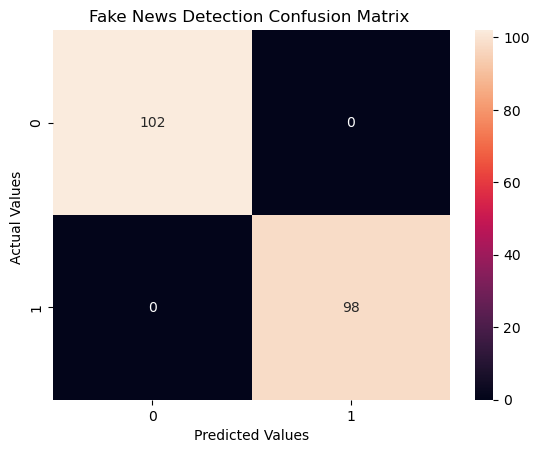

In [38]:
# Step No 16 : Create Confusion Matrix  Heatmap

sns.heatmap(cm , 
            annot=True ,
            fmt= "d") 

# Set Title 
plt.title("Fake News Detection Confusion Matrix ")

# Set x-axis label 
plt.xlabel("Predicted Values")

# Set y-axis label 
plt.ylabel("Actual Values ")

# Save the Heatmap 
plt.savefig("Confusion Matrix Heatmap .png")

# Display the heatmap 
plt.show()

In [39]:
# Step No 17 : Prediction Probability 

# Predict Probability 
probability = model.predict_proba(
    X_test_vectorized
)
# Display Probability 
print("\nPrediction Probability : ")
print(probability[:10])


Prediction Probability : 
[[8.22296171e-06 9.99991777e-01]
 [1.54401127e-06 9.99998456e-01]
 [9.99999213e-01 7.86609831e-07]
 [3.43576589e-06 9.99996564e-01]
 [2.78478156e-06 9.99997215e-01]
 [2.21587521e-06 9.99997784e-01]
 [9.99998453e-01 1.54688330e-06]
 [9.99998060e-01 1.93999553e-06]
 [9.99996655e-01 3.34488950e-06]
 [9.99997826e-01 2.17398776e-06]]


In [40]:
# Step No 18 : User Input 
# Take news title from user 
user_title = input("\nEnter News Title : ")

# Take news content from user 
user_text = input("Enter News Text : ")

In [41]:
# Step No 19 : Combine User Input 
user_news = (
    user_title + " " + user_text
)

In [42]:
# Step No 20 : Vectorize User News 
# Convert user news into TF-IDF vector 
user_vectorized = vectorizer.transform(
    [user_news]
)

In [43]:
# Step No 21 : Predict User News 
# Predict Fake or Real 
result = model.predict(user_vectorized)

In [44]:
# Step No 22 : Predict Probability 
# Get prediction probabilities 
result_probability = model.predict_proba(
    user_vectorized
)

In [45]:
# Step No 23 : Final Output 
print("\n==================================")

print("       FAKE NEWS DETECTION")

print("====================================")

print("Predicted Result : " , result[0])

print("Fake Probability : ", round(result_probability[0][0] * 100 ,
                                   2),"%")

print("Real Probability : " , 
      round(
          result_probability[0][0] * 100 ,
          2
          ),
      "%"
      )

print("===========================================")


       FAKE NEWS DETECTION
Predicted Result :  Real
Fake Probability :  49.88 %
Real Probability :  49.88 %
